**Project Code:** P001-MVB
**Stage:** 03_MVB_EDA
**Notebook Version:** v1.0
**Author:** Abubakar Amidu
**Programme:** 3MTT DeepTech Cohort 2 — DS/ML Mentorship
**Last Updated:** 24 July 2026

---

# MVB-03 — Exploratory Data Analysis

**Project:** P001-MVB — Explainable and Responsible AI for Differentiating Bacterial and Viral Meningitis: A Clinical Decision Support System

## Purpose

Explore the cleaned dataset's distributions, relationships, and separability characteristics to inform feature engineering and model development decisions in later stages.

## Inputs

- `MVB-02-cleaned-data/MVB-02-meningitis-cleaned.csv` (Stage 02 output)

## Outputs

- Figures: `MVB-03-figures/` (6 visualizations)
- Result tables: `MVB-03-results/` (correlation matrix, feature summary statistics, separability analysis, diagnosis distribution, gender/pathogen crosstabs)
- This notebook
- Updated documentation

In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

# Set working directory to Stage 03 folder
import os
os.chdir('/content/drive/MyDrive/P001-MVB/03_MVB_EDA')

In [ ]:
# Ensure output folders exist
import os

os.makedirs("MVB-03-figures", exist_ok=True)
os.makedirs("MVB-03-results", exist_ok=True)

In [ ]:
# Imports for data handling and visualization
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Reproducibility standard — establishes a consistent seed for this and future stages
np.random.seed(42)

In [ ]:
# Load the cleaned dataset produced in Stage 02
df = pd.read_csv("../02_MVB_Data-Preparation/MVB-02-cleaned-data/MVB-02-meningitis-cleaned.csv")
print("Shape loaded:", df.shape)

Shape loaded: (1133, 14)


In [ ]:

# Confirm the data matches Stage 02's documented output before proceeding
assert df.shape == (1133, 14)
assert df["Diagnosis"].nunique() == 2
print("Integrity check passed: shape and binary target confirmed.")

Integrity check passed: shape and binary target confirmed.


## Exploratory Analyses

### 1. Class Balance

Diagnosis
Bacterial    595
Viral        538
Name: count, dtype: int64


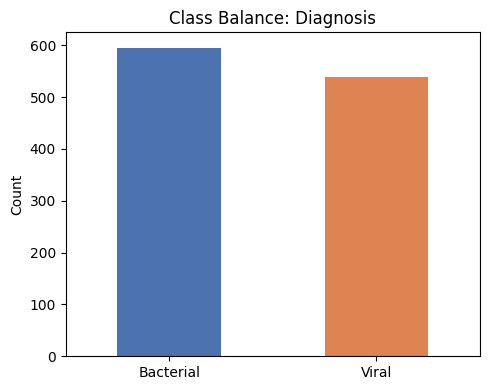

In [ ]:

# Class balance — counts and bar chart
print(df["Diagnosis"].value_counts())

fig, ax = plt.subplots(figsize=(5,4))
df["Diagnosis"].value_counts().plot(kind="bar", color=["#4C72B0","#DD8452"], ax=ax)
ax.set_title("Class Balance: Diagnosis")
ax.set_ylabel("Count")
ax.set_xlabel("")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("MVB-03-figures/fig-01-class-balance.png", dpi=150)
plt.show()

### 2. CSF Marker Distributions by Diagnosis

The three core CSF biomarkers (WBC_Count, Protein_Level, Glucose_Level) are visualized by diagnosis class, consistent with the clinical plausibility check performed in Stage 01.

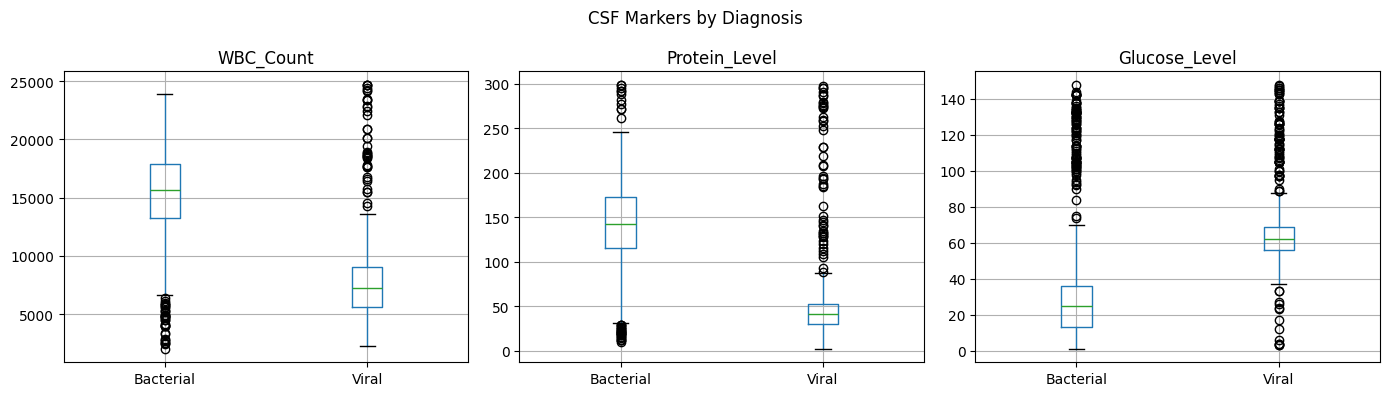

In [ ]:

# Boxplots of the three core CSF markers, split by diagnosis class
csf_cols = ["WBC_Count", "Protein_Level", "Glucose_Level"]
fig, axes = plt.subplots(1, 3, figsize=(14,4))
for ax, col in zip(axes, csf_cols):
    df.boxplot(column=col, by="Diagnosis", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("CSF Markers by Diagnosis")
plt.tight_layout()
plt.savefig("MVB-03-figures/fig-02-csf-boxplots.png", dpi=150)
plt.show()

### 3. Correlation Analysis

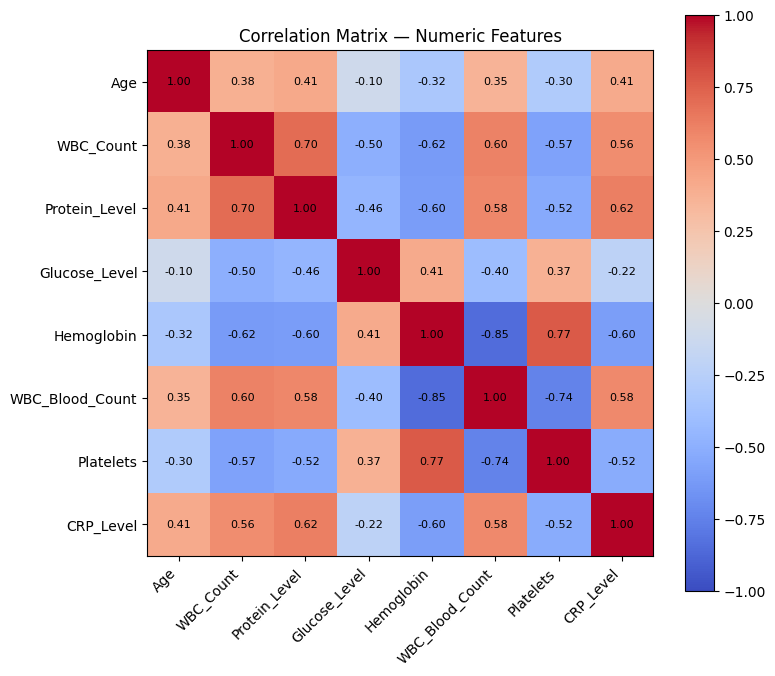

                   Age  WBC_Count  Protein_Level  Glucose_Level  Hemoglobin  \
Age              1.000      0.376          0.415         -0.105      -0.324   
WBC_Count        0.376      1.000          0.700         -0.496      -0.616   
Protein_Level    0.415      0.700          1.000         -0.460      -0.605   
Glucose_Level   -0.105     -0.496         -0.460          1.000       0.407   
Hemoglobin      -0.324     -0.616         -0.605          0.407       1.000   
WBC_Blood_Count  0.353      0.604          0.584         -0.404      -0.848   
Platelets       -0.296     -0.575         -0.524          0.368       0.768   
CRP_Level        0.414      0.561          0.620         -0.217      -0.600   

                 WBC_Blood_Count  Platelets  CRP_Level  
Age                        0.353     -0.296      0.414  
WBC_Count                  0.604     -0.575      0.561  
Protein_Level              0.584     -0.524      0.620  
Glucose_Level             -0.404      0.368     -0.217  
Hem

In [ ]:

# Correlation matrix across all numeric features, visualized as a heatmap
numeric_cols = ["Age", "WBC_Count", "Protein_Level", "Glucose_Level",
                 "Hemoglobin", "WBC_Blood_Count", "Platelets", "CRP_Level"]
corr = df[numeric_cols].corr().round(3)

fig, ax = plt.subplots(figsize=(8,7))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(numeric_cols)))
ax.set_yticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=45, ha="right")
ax.set_yticklabels(numeric_cols)
for i in range(len(numeric_cols)):
    for j in range(len(numeric_cols)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=8)
plt.colorbar(im)
ax.set_title("Correlation Matrix — Numeric Features")
plt.tight_layout()
plt.savefig("MVB-03-figures/fig-03-correlation-heatmap.png", dpi=150)
plt.show()

# Save the correlation matrix as a reusable results table
corr.to_csv("MVB-03-results/correlation-matrix.csv")
print(corr)

**Observation:** Several moderate-to-strong correlations exist among features (e.g. Hemoglobin–Platelets: 0.77, WBC_Blood_Count–Platelets: -0.74, WBC_Count–Protein_Level: 0.70). This is relevant to Stage 04 feature selection, particularly for models sensitive to multicollinearity.

### 4. Age Distribution by Diagnosis

Within this dataset, the age distribution differs between diagnosis classes. This is a descriptive observation only and should not be interpreted as evidence of real-world epidemiological patterns.

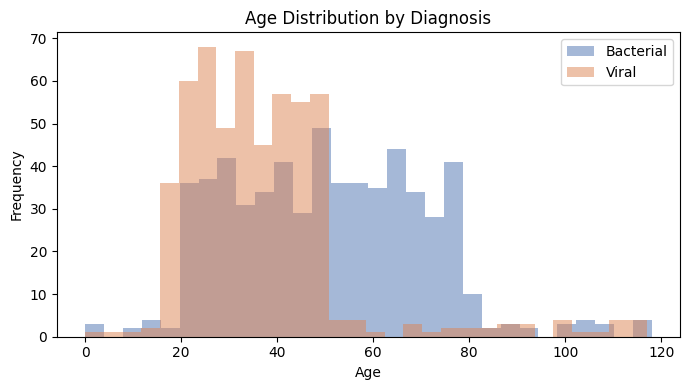

In [ ]:

# Age distribution, overlaid by diagnosis class
fig, ax = plt.subplots(figsize=(7,4))
df[df["Diagnosis"]=="Bacterial"]["Age"].plot(kind="hist", bins=30, alpha=0.5, label="Bacterial", ax=ax, color="#4C72B0")
df[df["Diagnosis"]=="Viral"]["Age"].plot(kind="hist", bins=30, alpha=0.5, label="Viral", ax=ax, color="#DD8452")
ax.set_title("Age Distribution by Diagnosis")
ax.set_xlabel("Age")
ax.legend()
plt.tight_layout()
plt.savefig("MVB-03-figures/fig-04-age-distribution.png", dpi=150)
plt.show()

### 5. Categorical Variables vs. Diagnosis

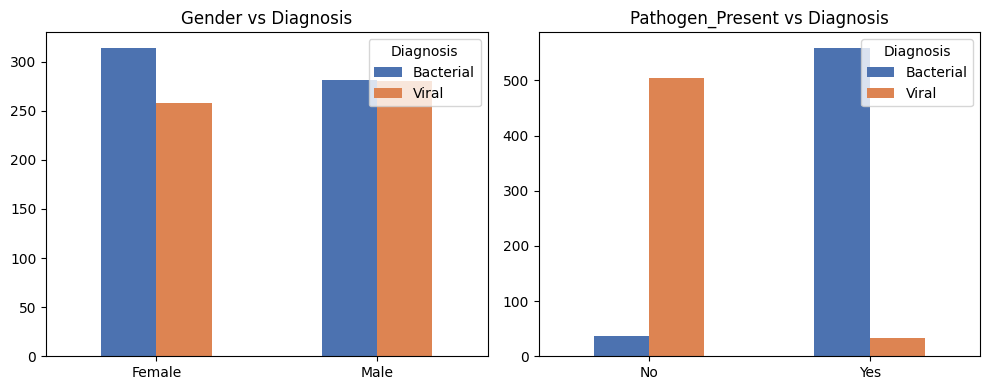

Diagnosis         Bacterial  Viral
Pathogen_Present                  
No                       36    504
Yes                     559     34

Diagnosis  Bacterial  Viral
Gender                     
Female           314    258
Male             281    280


In [ ]:

# Categorical variables vs. Diagnosis — Gender and Pathogen_Present
fig, axes = plt.subplots(1, 2, figsize=(10,4))
pd.crosstab(df["Gender"], df["Diagnosis"]).plot(kind="bar", ax=axes[0], color=["#4C72B0","#DD8452"])
axes[0].set_title("Gender vs Diagnosis")
axes[0].set_xlabel("")
plt.setp(axes[0].get_xticklabels(), rotation=0)

pd.crosstab(df["Pathogen_Present"], df["Diagnosis"]).plot(kind="bar", ax=axes[1], color=["#4C72B0","#DD8452"])
axes[1].set_title("Pathogen_Present vs Diagnosis")
axes[1].set_xlabel("")
plt.setp(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.savefig("MVB-03-figures/fig-05-categorical-vs-diagnosis.png", dpi=150)
plt.show()

# Exact counts behind the chart above
print(pd.crosstab(df["Pathogen_Present"], df["Diagnosis"]))
print()
print(pd.crosstab(df["Gender"], df["Diagnosis"]))

# Export crosstabs so every figure has a matching data table
pd.crosstab(df["Gender"], df["Diagnosis"]).to_csv("MVB-03-results/gender-vs-diagnosis.csv")
pd.crosstab(df["Pathogen_Present"], df["Diagnosis"]).to_csv("MVB-03-results/pathogen-vs-diagnosis.csv")

### 6. Blood Markers by Diagnosis

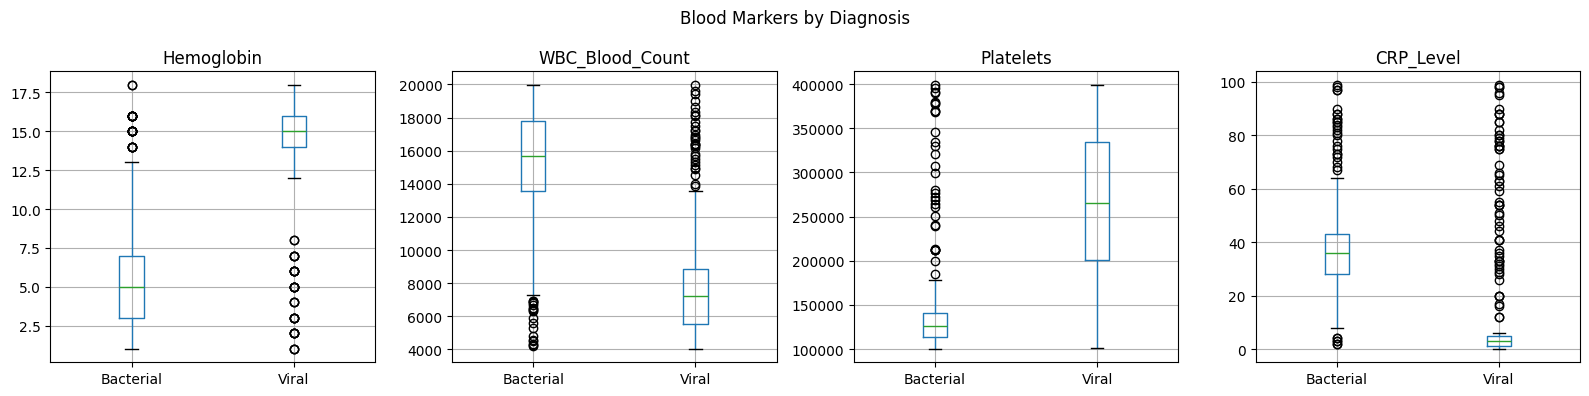

--- Hemoglobin ---
           mean  median
Diagnosis              
Bacterial   5.4     5.0
Viral      14.5    15.0

--- WBC_Blood_Count ---
              mean   median
Diagnosis                  
Bacterial  15427.5  15698.0
Viral       7615.7   7239.5

--- Platelets ---
               mean    median
Diagnosis                    
Bacterial  134893.5  126412.0
Viral      265750.0  265253.0

--- CRP_Level ---
           mean  median
Diagnosis              
Bacterial  36.7    36.0
Viral       8.5     3.0



In [ ]:

# Boxplots of blood markers, split by diagnosis class
blood_cols = ["Hemoglobin", "WBC_Blood_Count", "Platelets", "CRP_Level"]
fig, axes = plt.subplots(1, 4, figsize=(16,4))
for ax, col in zip(axes, blood_cols):
    df.boxplot(column=col, by="Diagnosis", ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
plt.suptitle("Blood Markers by Diagnosis")
plt.tight_layout()
plt.savefig("MVB-03-figures/fig-06-blood-markers-boxplot.png", dpi=150)
plt.show()

# Mean/median summary behind the boxplots above
for col in blood_cols:
    print(f"--- {col} ---")
    print(df.groupby("Diagnosis")[col].agg(["mean","median"]).round(1))
    print()

## Separability Analysis

Beyond visual distributions, this section quantifies how strongly individual features separate the two diagnosis classes — to check whether the dataset behaves consistently with real-world clinical data or shows signs of artificial separability.

**Method:** For each numeric feature, a naive single-variable threshold classifier was built using the midpoint between the Bacterial and Viral class medians, then scored against the actual `Diagnosis` labels.

In [ ]:

# Separability analysis: how well does each feature predict Diagnosis on its own?
sep_results = []

# Pathogen_Present — categorical class-match rate
pathogen_match = ((df["Pathogen_Present"]=="Yes") == (df["Diagnosis"]=="Bacterial")).mean()
sep_results.append({"Feature":"Pathogen_Present","Type":"Categorical","Metric":"Class match rate","Value":f"{pathogen_match*100:.1f}%"})

# Numeric features — naive threshold accuracy (midpoint of class medians)
for col, direction in [("Hemoglobin","low_bacterial"), ("Platelets","low_bacterial"),
                        ("WBC_Blood_Count","high_bacterial"), ("CRP_Level","high_bacterial")]:
    bact_median = df[df["Diagnosis"]=="Bacterial"][col].median()
    vir_median = df[df["Diagnosis"]=="Viral"][col].median()
    threshold = (bact_median + vir_median) / 2
    pred_bacterial = df[col] < threshold if direction=="low_bacterial" else df[col] > threshold
    accuracy = (pred_bacterial == (df["Diagnosis"]=="Bacterial")).mean()
    sep_results.append({"Feature":col,"Type":"Numeric","Metric":"Naive threshold accuracy","Value":f"{accuracy*100:.1f}%"})

sep_df = pd.DataFrame(sep_results)
sep_df.to_csv("MVB-03-results/separability-analysis.csv", index=False)
print(sep_df)

            Feature         Type                    Metric  Value
0  Pathogen_Present  Categorical          Class match rate  93.8%
1        Hemoglobin      Numeric  Naive threshold accuracy  93.8%
2         Platelets      Numeric  Naive threshold accuracy  86.0%
3   WBC_Blood_Count      Numeric  Naive threshold accuracy  93.8%
4         CRP_Level      Numeric  Naive threshold accuracy  93.7%


**Finding:** `Pathogen_Present` is an almost perfect single-variable predictor (94% class match). Several blood markers independently achieve 86–94% naive threshold accuracy on their own. No single lab value in real-world meningitis diagnosis achieves this level of standalone predictive power — clinical practice relies on combining multiple markers precisely because individual values are rarely this decisive.

The observed feature separability is consistent with a dataset that may have been synthetically generated or intentionally curated to exhibit stronger class separation than is typical of real-world clinical datasets. This cannot be confirmed from the available documentation.

This pattern, combined with the non-standard `WBC_Count` scale identified in Stage 02, indicates the dataset is **clinically-inspired but not clinically-calibrated**.

**Implications:**
- **Stage 04:** `Pathogen_Present` flagged as a candidate for exclusion or comparative modeling (with/without).
- **Stage 05–06:** Expect high model accuracy — interpret as a property of the dataset, not evidence of real-world generalizability.
- **Stage 08:** This finding directly supports the Model Card's limitations — model is not validated on real clinical data and is unsuitable for deployment without further validation.

## Export Result Tables

In [ ]:

# Feature summary statistics by diagnosis class — saved as a reusable results table
numeric_cols = ["Age", "WBC_Count", "Protein_Level", "Glucose_Level",
                 "Hemoglobin", "WBC_Blood_Count", "Platelets", "CRP_Level"]

summary_rows = []
for col in numeric_cols:
    for diag in ["Bacterial", "Viral"]:
        subset = df[df["Diagnosis"]==diag][col]
        summary_rows.append({
            "Feature": col, "Diagnosis": diag,
            "Mean": round(subset.mean(),2), "Median": subset.median(),
            "Min": subset.min(), "Max": subset.max(), "Std": round(subset.std(),2)
        })
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv("MVB-03-results/feature-summary-statistics.csv", index=False)
print(summary_df)

            Feature  Diagnosis       Mean    Median     Min     Max       Std
0               Age  Bacterial      50.83      51.0       0     118     20.15
1               Age      Viral      37.05      34.0       0     117     17.43
2         WBC_Count  Bacterial   15039.53   15629.0    2008   23870   3928.03
3         WBC_Count      Viral    8034.33    7274.0    2304   24716   3861.58
4     Protein_Level  Bacterial     139.36     142.0      10     299     50.98
5     Protein_Level      Viral      53.70      41.0       2     297     50.74
6     Glucose_Level  Bacterial      36.27      25.0       1     148     37.54
7     Glucose_Level      Viral      68.03      62.0       3     148     24.02
8        Hemoglobin  Bacterial       5.36       5.0       1      18      3.31
9        Hemoglobin      Viral      14.46      15.0       1      18      3.15
10  WBC_Blood_Count  Bacterial   15427.45   15698.0    4210   19991   3122.82
11  WBC_Blood_Count      Viral    7615.71    7239.5    4022   19

## Summary

- Class balance confirmed: 595 Bacterial (52.5%), 538 Viral (47.5%) — reasonably balanced.
- CSF markers (WBC_Count, Protein_Level, Glucose_Level) show clinically plausible separation between classes, consistent with Stage 01.
- Moderate-to-strong correlations exist among several features — relevant to Stage 04 feature selection.
- `Pathogen_Present` is a near-perfect predictor of `Diagnosis` (94% match) — flagged for Stage 04 decision.
- Blood markers (Hemoglobin, WBC_Blood_Count, CRP_Level, Platelets) independently achieve 86–94% naive threshold classification accuracy — well beyond real-world clinical separability.
- The observed feature separability is consistent with a dataset that may have been synthetically generated or intentionally curated to exhibit stronger class separation than is typical of real-world clinical datasets. This cannot be confirmed from the available documentation.
- No preprocessing changes were made during Stage 03; Stage 04 begins from the unchanged Stage 02 cleaned dataset.

---

## Stage Status

**Stage:** Completed

**Primary Outputs Produced:**
✓ 6 figures (MVB-03-figures/)
✓ 6 result tables (MVB-03-results/): correlation matrix, feature summary statistics, separability analysis, diagnosis distribution, gender-vs-diagnosis, pathogen-vs-diagnosis
✓ EDA notebook
✓ Updated documentation

**Input for Next Stage:**
`MVB-02-cleaned-data/MVB-02-meningitis-cleaned.csv` (unchanged — no rows/columns modified in Stage 03)

**Next Stage:**
04_MVB_Feature-Engineering

In [20]:

# Notebook completion timestamp and environment info — useful when rerunning months/years later
from datetime import datetime
import platform

print("="*60)
print("Stage 03 completed successfully")
print("Completion time:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print("Python:", platform.python_version())
print("Pandas:", pd.__version__)
print("Matplotlib:", plt.matplotlib.__version__)
print("="*60)

Stage 03 completed successfully
Completion time: 2026-07-25 09:15:33
Python: 3.12.13
Pandas: 2.2.2
Matplotlib: 3.10.0
